# **Cell 1: Install Dependencies**

In [1]:
%%capture
!pip install -q torch torchvision grad-cam scikit-learn matplotlib seaborn

# **Cell 2: Import Libraries**

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# **Cell 3: Download Dataset from Kaggle**

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d data/
!rm chest-xray-pneumonia.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:55<00:00, 21.3MB/s]

replace data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/._test? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/._train? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/test/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/test/._NORMAL? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/test/._PNEUMONIA? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/chest_xray/__MACOSX/chest_xray/test/NO

# **Cell 4: Define Data Transforms**

In [4]:
DATA_DIR = "data/chest_xray"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# **Cell 5: Load Datasets and Split Train/Val**

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_test_transform)

val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
val_dataset.dataset.transform = val_test_transform

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.dataset.classes}")

Train: 4695 | Val: 521 | Test: 624
Classes: ['NORMAL', 'PNEUMONIA']


# **Cell 6: Compute Class Weights and Build DataLoaders**

In [6]:
targets = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

sample_weights = np.array([class_weights[t].item() for t in targets])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Class weights: tensor([1.4909, 0.5091], device='cuda:0')


# **Cell 7: Build ResNet-50 Model**

In [7]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)
model = model.to(device)

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Total params: 23,512,130


# **Cell 8: Define Loss, Optimizer, and Scheduler**

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# **Cell 9: Define Training and Evaluation Functions**

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc

# **Cell 10: Stage 1 Training with Early Stopping (Freeze Backbone)**

In [10]:
# Freeze all layers except the classifier
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

EPOCHS_STAGE1 = 15
PATIENCE = 3
MIN_DELTA = 1e-4

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE1):
    # Train
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    # Validate
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    # Early Stopping check (based on validation AUC)
    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_pneumonia_stage1.pth")
        print(f"  ✓ Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  ⚠ No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\n Early stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    # Step scheduler
    scheduler.step()

# Restore best weights
if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\n Best weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

Epoch 1/15 | TL: 0.2690 TA: 0.8296 | VL: 0.2453 VA: 0.8580 AUC: 0.9798
  ✓ Best model saved (AUC: 0.9798)
Epoch 2/15 | TL: 0.1714 TA: 0.9110 | VL: 0.2046 VA: 0.8829 AUC: 0.9839
  ✓ Best model saved (AUC: 0.9839)
Epoch 3/15 | TL: 0.1483 TA: 0.9227 | VL: 0.1680 VA: 0.9194 AUC: 0.9864
  ✓ Best model saved (AUC: 0.9864)
Epoch 4/15 | TL: 0.1252 TA: 0.9384 | VL: 0.1703 VA: 0.9136 AUC: 0.9871
  ✓ Best model saved (AUC: 0.9871)
Epoch 5/15 | TL: 0.1230 TA: 0.9327 | VL: 0.1692 VA: 0.9117 AUC: 0.9879
  ✓ Best model saved (AUC: 0.9879)
Epoch 6/15 | TL: 0.1127 TA: 0.9440 | VL: 0.1528 VA: 0.9290 AUC: 0.9877
  ⚠ No improvement for 1/3 epochs
Epoch 7/15 | TL: 0.1162 TA: 0.9395 | VL: 0.1512 VA: 0.9309 AUC: 0.9878
  ⚠ No improvement for 2/3 epochs
Epoch 8/15 | TL: 0.1082 TA: 0.9472 | VL: 0.1445 VA: 0.9405 AUC: 0.9883
  ✓ Best model saved (AUC: 0.9883)
Epoch 9/15 | TL: 0.0997 TA: 0.9523 | VL: 0.1595 VA: 0.9175 AUC: 0.9883
  ⚠ No improvement for 1/3 epochs
Epoch 10/15 | TL: 0.0994 TA: 0.9508 | VL: 0.1470 

# **Cell 11: Unfreeze Full Network for Fine-tuning**

In [11]:
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable_params:,} / Total: {total_params:,}")

Trainable: 23,512,130 / Total: 23,512,130


# **Cell 12: Reconfigure Optimizer and Scheduler for Fine-tuning**

In [12]:
# Smaller learning rate for fine-tuning the whole network
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# **Cell 13: Stage 2 Training with Early Stopping**

In [13]:
EPOCHS_STAGE2 = 20
PATIENCE = 3
MIN_DELTA = 1e-4

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE2):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE2} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_pneumonia_resnet50.pth")
        print(f"  ✓ Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  ⚠ No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\n Early stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    scheduler.step()

if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\n Best weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

Epoch 1/20 | TL: 0.0532 TA: 0.9751 | VL: 0.1087 VA: 0.9578 AUC: 0.9939
  ✓ Best model saved (AUC: 0.9939)
Epoch 2/20 | TL: 0.0223 TA: 0.9900 | VL: 0.0744 VA: 0.9770 AUC: 0.9982
  ✓ Best model saved (AUC: 0.9982)
Epoch 3/20 | TL: 0.0090 TA: 0.9962 | VL: 0.0783 VA: 0.9808 AUC: 0.9980
  ⚠ No improvement for 1/3 epochs
Epoch 4/20 | TL: 0.0076 TA: 0.9974 | VL: 0.1092 VA: 0.9770 AUC: 0.9972
  ⚠ No improvement for 2/3 epochs
Epoch 5/20 | TL: 0.0033 TA: 0.9991 | VL: 0.0790 VA: 0.9827 AUC: 0.9982
  ⚠ No improvement for 3/3 epochs

 Early stopping triggered at epoch 5.
   Best epoch was 2 with AUC = 0.9982

 Best weights restored from epoch 2 (AUC: 0.9982)


# **Cell 14: Plot Training History**

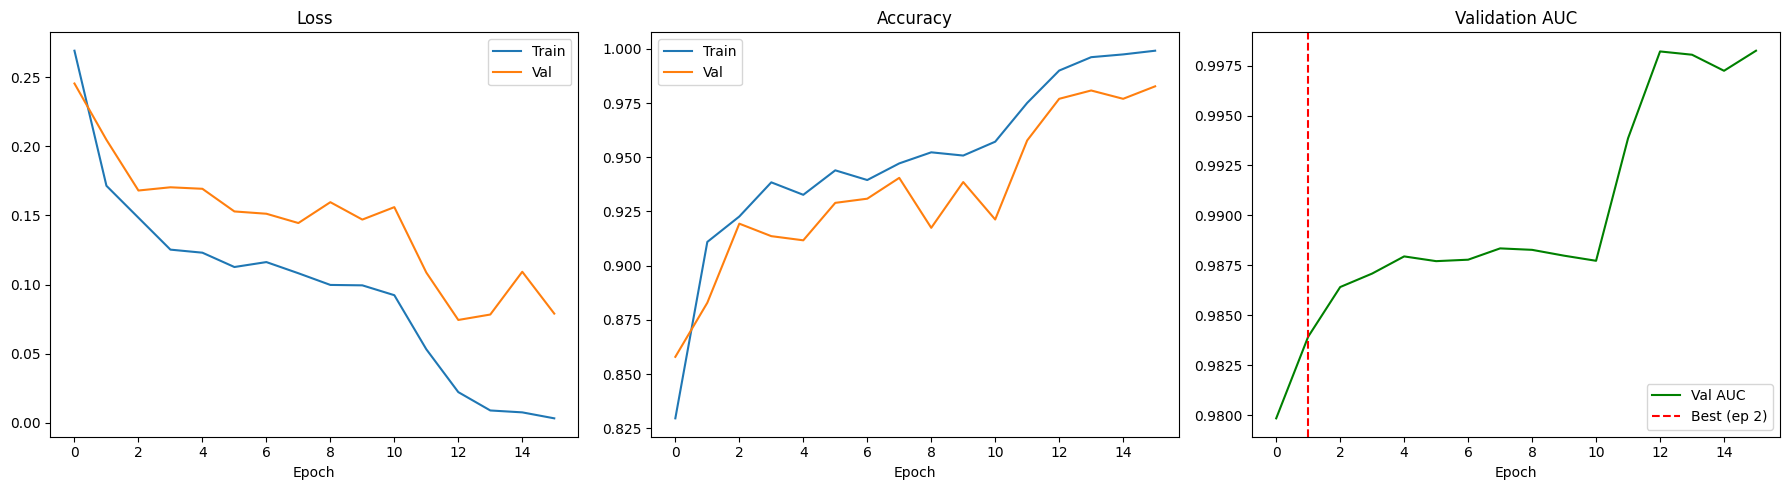

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["val_auc"], label="Val AUC", color="green")
axes[2].axvline(x=best_epoch - 1, color="red", linestyle="--", label=f"Best (ep {best_epoch})")
axes[2].set_title("Validation AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

# **Cell 15: Evaluate on Test Set**

In [15]:
model.load_state_dict(torch.load("best_pneumonia_resnet50.pth"))
test_loss, test_acc, test_auc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

Test Loss: 0.6466 | Test Acc: 0.8478 | Test AUC: 0.9736

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.60      0.75       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624



# **Cell 16: Plot Confusion Matrix and ROC Curve**

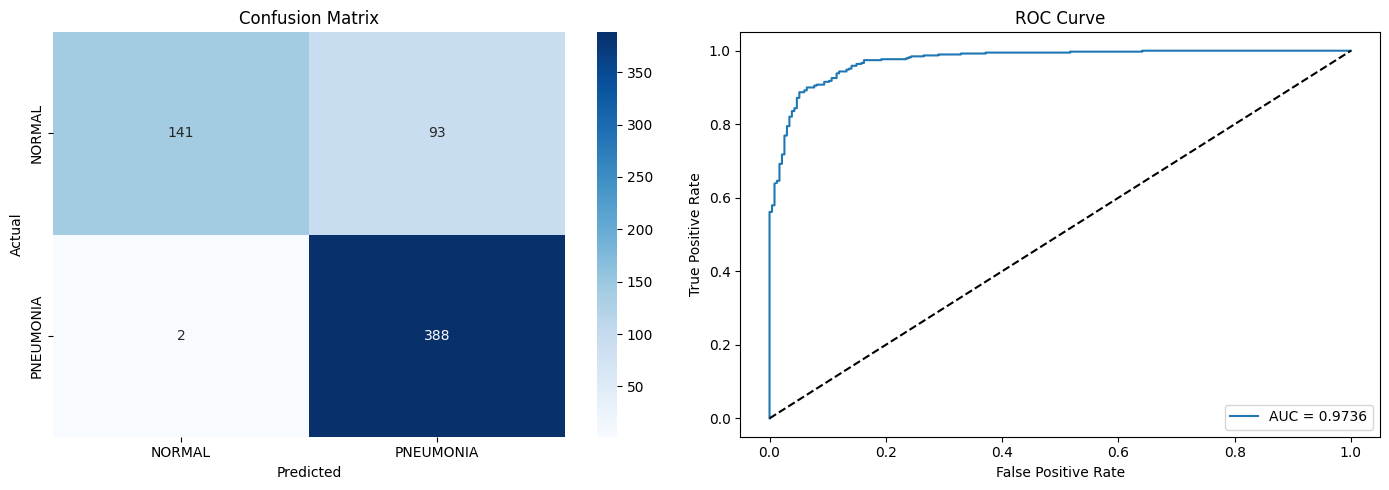

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

model.eval()
probs = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
fpr, tpr, _ = roc_curve(all_labels, probs)
axes[1].plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

# **Cell 17: Interpretability with Grad-CAM**

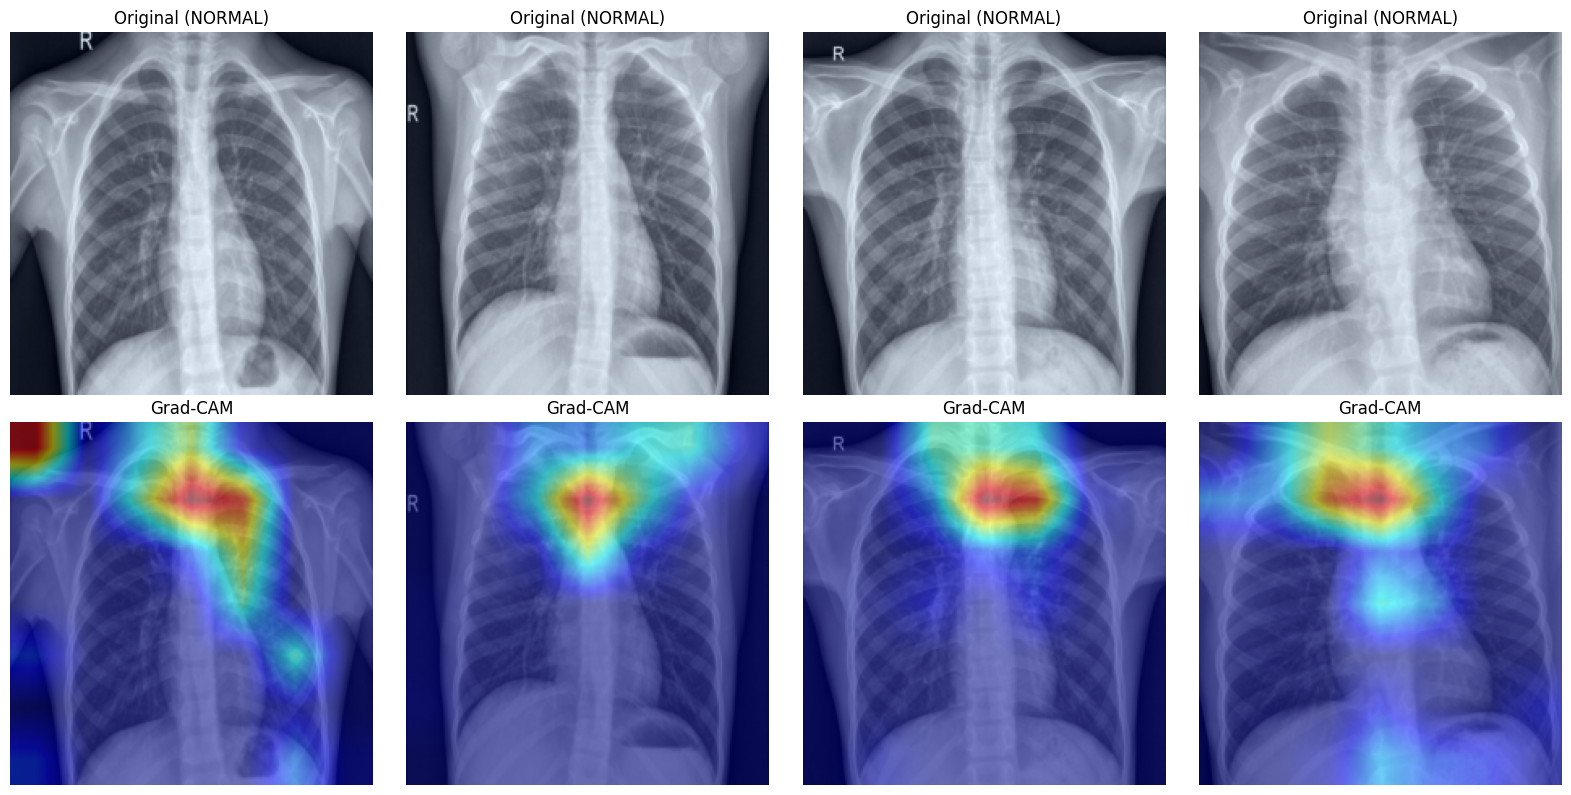

In [17]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:4].to(device)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_tensor = sample_images[i:i+1]
    grayscale_cam = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(1)])[0]

    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np); axes[0, i].set_title(f"Original ({['NORMAL','PNEUMONIA'][sample_labels[i]]})"); axes[0, i].axis("off")
    axes[1, i].imshow(cam_image); axes[1, i].set_title("Grad-CAM"); axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()

# **Cell 18: Save Model Weights and Config**

In [18]:
torch.save(model.state_dict(), "pneumonia_resnet50_weights.pth")

config = {
    "architectures": ["ResNetForImageClassification"],
    "model_type": "resnet",
    "num_labels": 2,
    "id2label": {0: "NORMAL", 1: "PNEUMONIA"},
    "label2id": {"NORMAL": 0, "PNEUMONIA": 1},
}
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Files saved:")
print("  - pneumonia_resnet50_weights.pth")
print("  - config.json")

Files saved:
  - pneumonia_resnet50_weights.pth
  - config.json


# **Cell 19: Download Files from Colab**

In [19]:
from google.colab import files

files.download("pneumonia_resnet50_weights.pth")
files.download("config.json")
files.download("training_history.png")
files.download("results.png")
files.download("gradcam.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>